## Business Problem
Shopping for an electric vehicle (EV) could be a difficult task given the broad range of car manufacturers in the market, as well as the abundance of features to consider such as: battery capacity, driving range, vehicle size, and other performance characteristics. Examining all these features could be overwhelming, often times it's not transparent how these attributes influence price, which increases the risk of overpaying for a vehicle or overlooking great value.

The purpose of this effort is to develop a supervised machine learning regression model that predicts the expected market price of an EV based on its physical and performance attributes. Through existing EV market data, the model can estimate a reasonable price range for a given vehicle configuration (i.e. hatchback with a specific range and battery size). This allows a consumer to compare the listed price to the model's predicted range and make a more informed purchase decision.

This a standard analysis flow where all efforts start with understanding the business problem, followed by understanding the data, preprocessing, training the model, evaluating performance, and optimizing it. The ouputs of this effort are intended to support consumer decisions such as budgeting, comparing features for tradeoff, and identifying listings that are overpriced and underpriced in compmarison to other EVs.

## Machine Learning Applications

The machine learning approach and framework applies to a wide range of business use-cases across industries, regardless of regions. Listed below are a few examples:

1. For businesses attempting to enter into a market, regardless if it's a niche or broad, they perform a similar analysis in order to develop pricing, marketing, and growth strategies, to name a few. If we take the EV market as an example, manufacturers and marketplaces analyze attributes such as body style, performance, and range to estimate competitive price points. Machine learning regression models support this process by identifying relationships between product features and market prices, helping inform pricing, marketing, and growth strategies (Naaz et al., 2025).

2. Another example of a machine learning application in business is seen in the financial services industry, particularly in investment analysis and valuation. Investors evaluate a company/stock to competitors by examining attributes such as earnings, revenue growth, and financial ratios. These features are weighted and analyzed using regression or predictive models to estimate future value or expected return (Sangeetha & Alfia, 2024). Similar to the EV example, vehicle attributes are used as inputs to predict a monetary outcome.

4. The last example is in the healthcare industry, where machine learning is used to improve operational efficiency and resource planning. Healthcare administrators analyze patient data to identify factors associated with missed appointments, which can lead to lost revenue and inefficient use of resources. Specifically, classification models such as logistic regression are applied to estimate the likelihood of a patient missing an appointment based on historical and demographic attributes (Hamdan & Abu Bakar, 2023). It's important to note that the underlying machine learning framework of feature analysis and prediction is similar though the model differs from regression.

## Machine Learning Algorithms

For this assignment we used multiple machine learning algorithms to not only arrive at a deterministic value, but to also manage overfitting. The machine learning algorithms used in this assignment are:

1. Linear Regression - Used as a baseline model to predict EV prices based on various features and their associated coefficients.
    - Strengths - It provides a direct and fast approach to generating predictions and makes it easy to understand how each feature contributes to the predicted value.
    - Weaknesses - Since the model assumes a linear relationship between features and target variable, it may limit its ability to identify more complex patterns in the data.

2. Ridge Regression - A regularization technique that shrinks coefficient values to reduce model complexity and manage overfitting.
    - Strengths - This approach keeps all features in the model while reducing the impact of high correlated variables, leading to a more stable performance.
    - Weaknesses - Performance results may be skewed by less important features because coefficients are only reduced and not removed.

3. Lasso Regression - This regularizaiton technique removes least important features by shrinking coefficients to zero to manage overfitting.
    - Strengths - It performs feature selection by removing least important ones which simplifies the model and improves interpretation.
    - Weaknesses - If features are highly correlated, Lasso may select one feature and discard others, which leads to inconsitent feature selection.

## Data Preprocessing Discussion

As an overview for the following cells, we first had to import the applicable libraries and functions required to compute and visualize the data. Overall, the EV dataset was prepared for regression modeling by cleaning text-based numerical values and converting them into numeric form, encoding categorical variables, and removing fields that weren't productive nor appropriate for the regression models.

In [2]:
# Install the scikit-learn library into the active Jupyter kernel environment.
# The exclamation mark (!) tells Jupyter to run this as a system (shell) command
# instead of normal Python code.
#
# scikit-learn is required for:
# - train_test_split
# - LinearRegression, Ridge, and Lasso
# - model evaluation metrics (R2, MAE, RMSE)
#
# This command is typically used when the package is missing from the
!pip install scikit-learn

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn import metrics

In [4]:
# Specify the dataset file name.
# This makes it easy to reuse the notebook with a different dataset later
DATA_FILE = 'ElectricCarData.csv'

# Specify the target column we want to predict.
# In this case, we are predicting the price of an electric vehicle in euros
TARGET_COL = 'PriceEuro'

# Read the CSV file into a pandas DataFrame.
# This loads the EV dataset into memory so it can be explored and modeled
df = pd.read_csv('ElectricCarData.csv')

In [5]:
# Print a header to clearly label this output section in the notebook
print("--- Dataset Overview ---")

# Display structural information about the dataset:
# - Column names
# - Data types
# - Number of non-null values
# This helps identify missing values and columns that may need preprocessing
print(df.info())

# Print a header for the summary statistics section
print("/n--- Summary Statistics ---")

# Display descriptive statistics for numeric columns:
# - Count, mean, standard deviation, min, max, quartiles
# This provides an initial understanding of the data distribution and scale
print(df.describe())

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Brand        103 non-null    object
 1   Model        103 non-null    object
 2   Accel        103 non-null    object
 3   TopSpeed     103 non-null    object
 4   Range        103 non-null    object
 5   Efficiency   103 non-null    object
 6   FastCharge   103 non-null    object
 7   RapidCharge  103 non-null    object
 8   PowerTrain   103 non-null    object
 9   PlugType     103 non-null    object
 10  BodyStyle    103 non-null    object
 11  Segment      103 non-null    object
 12  Seats        103 non-null    int64 
 13  PriceEuro    103 non-null    int64 
dtypes: int64(2), object(12)
memory usage: 11.4+ KB
None
/n--- Summary Statistics ---
            Seats      PriceEuro
count  103.000000     103.000000
mean     4.883495   55811.563107
std      0.795834   34134.665

## Data Preprocessing (Data Cleaning)

The cell below is the bulk of our cleaning effort:

  * Removed the Model column since its values varied and would cause issues for our regression modeling effort.
  * Used a repeatable function to remove unit strings and return numeric values from columns that contained both numbers and text.
  * Each cell with a numeric value followed by a unit string was cleaned by dropping the string portion (i.e. 9.0 sec became 9.0). This enables the model to perform calculations on these features.
  * Since the Rapid Charge column comprised a string indicating whether or not rapid charging was available, it was converted to a binary numeric value.
  * For the purpose of this effort, the regression models require numeric inputs, which prompted the conversion of categorical features such as brand, body style, etc. into numeric columns.

In [6]:
# Create a copy of the original dataset so the raw data (df) stays unchanged
df_model = df.copy()

# Drop the 'Model' column because it is high-cardinality text and not suitable for direct regression input
df_model = df_model.drop(columns=["Model"])

# Define a helper function to clean numeric columns that contain numbers plus unit strings (e.g., "335 km")
def clean_numeric(series, suffix):
    return pd.to_numeric(
        # Convert each value to a string so we can remove text units safely
        series.astype(str)
              # Remove the unit suffix exactly as written (no regex pattern matching needed)
              .str.replace(suffix, "", regex=False)
              # Strip any extra whitespace left behind
              .str.strip(),
        # Convert values that still cannot be parsed into numbers into NaN (missing values)
        errors="coerce"
    )

# Convert acceleration from text to numeric (e.g., "9.0 sec" -> 9.0)
df_model["Accel"] = clean_numeric(df_model["Accel"], " sec")

# Convert top speed from text to numeric (e.g., "150 km/h" -> 150)
df_model["TopSpeed"] = clean_numeric(df_model["TopSpeed"], " km/h")

# Convert range from text to numeric (e.g., "335 km" -> 335)
df_model["Range"] = clean_numeric(df_model["Range"], " km")

# Convert efficiency from text to numeric (e.g., "188 Wh/km" -> 188)
df_model["Efficiency"] = clean_numeric(df_model["Efficiency"], " Wh/km")

# Convert fast charge speed from text to numeric (e.g., "350 km/h" -> 350)
df_model["FastCharge"] = clean_numeric(df_model["FastCharge"], " km/h")

# If the RapidCharge column exists, attempt to convert it into a binary numeric feature
if "RapidCharge" in df_model.columns:
    
    # Standardize RapidCharge values by converting to string, stripping whitespace, and lowercasing
    # This handles cases like " Yes", "YES", "yes", etc.
    rapid_clean = df_model["RapidCharge"].astype(str).str.strip().str.lower()
    
    # Map common yes/no variants into 1/0; anything else becomes NaN
    # This is defensive mapping to avoid turning everything into missing values
    df_model["RapidCharge"] = rapid_clean.map({
        "yes": 1, 
        "no": 0, 
        "y": 1, 
        "n": 0, 
        "true": 1, 
        "false": 0
    })

    # If RapidCharge is still entirely missing after mapping, drop it because it contains no usable data
    if df_model["RapidCharge"].isna().all():
        df_model = df_model.drop(columns=["RapidCharge"])

# One-hot encode all remaining categorical columns so regression models can use them
# drop_first=True prevents redundant dummy columns and helps avoid multicollinearity
df_model = pd.get_dummies(df_model, drop_first=True)

# Remove rows with missing target values because we cannot train a supervised model without the label
df_model = df_model.dropna(subset=[TARGET_COL])

# Fill missing numeric feature values using the median of each column (robust to outliers)
# This ensures regression models can train without NaN errors
df_model = df_model.fillna(df_model.median(numeric_only=True))

# Print total remaining missing values to confirm the dataset is ready for modeling
print("Total missing values after preprocessing:", df_model.isna().sum().sum())

# Display the final shape of the modeling dataset (rows, columns)
df_model.shape

Total missing values after preprocessing: 0


(103, 59)

# Metrics Explanation

The heatmap below displays the correlation of features across the data, including their relation to the target column (Price). Importantly, darker shades of red indicate strong positive correlations between features, vice versa for the color blue but with negative correlations. While some clusters of red/orange shades are present, especially in the top left, the heatmap comprises lighter colors spread across the matrix indicating that each feature isn't strongly or perfectly correlated to the price. This suggests that EV price isn't correlated to a single feature, but by multiple factors.

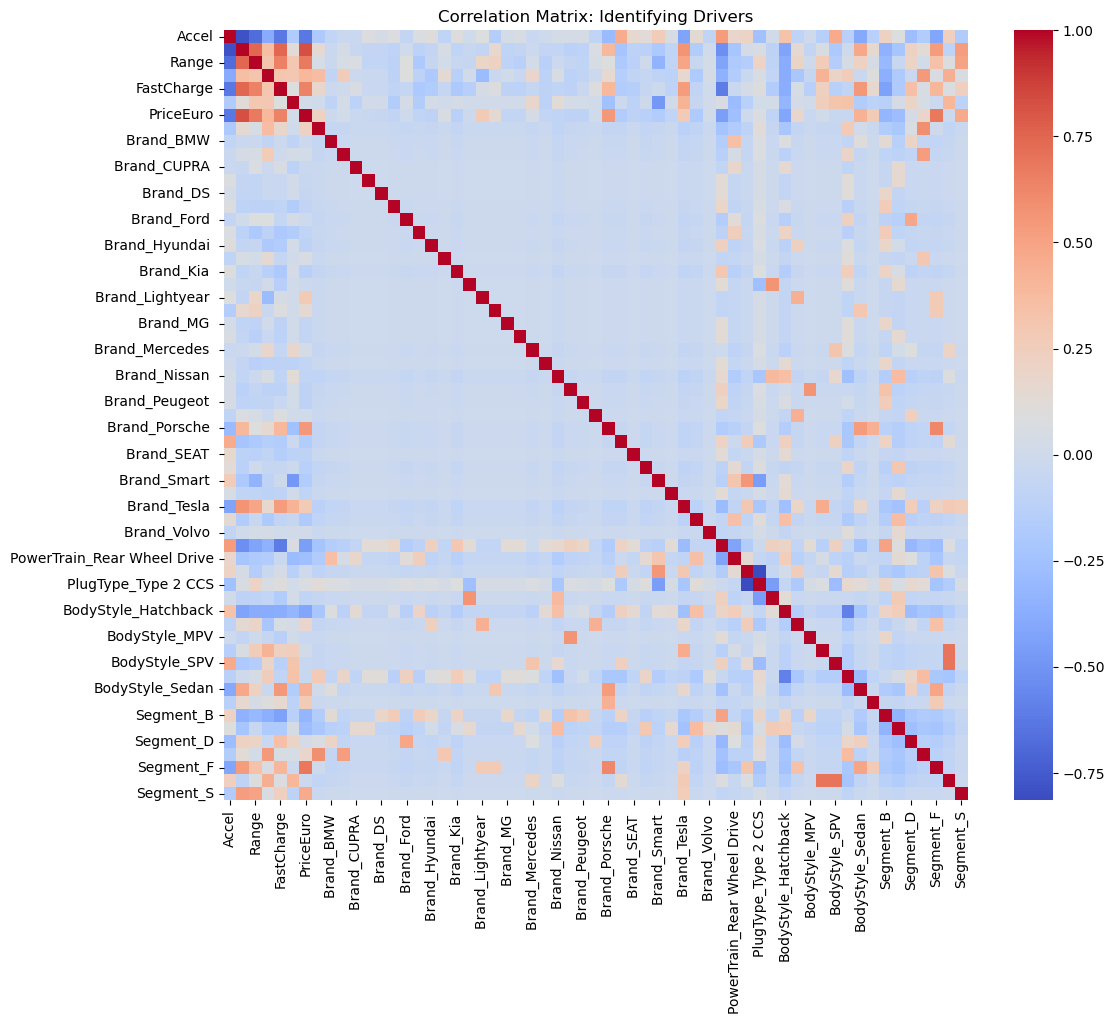

In [7]:
# Create a figure for the correlation heatmap
plt.figure(figsize=(12, 10))

# Plot a heatmap of correlations between numeric features
# This helps identify which features are most related to EV price
sns.heatmap(df_model.corr(numeric_only=True), cmap='coolwarm')

# Add a title to the plot for clarity
plt.title('Correlation Matrix: Identifying Drivers')

# Display the plot
plt.show()

In [8]:
# Separate the feature matrix (X) from the target variable (y)
# X contains all predictor columns (vehicle attributes) used to predict price
X = df_model.drop(columns=[TARGET_COL])

# y is the target column we are trying to predict (EV price)
y = df_model[TARGET_COL]

# Split the dataset into training and testing sets
# test_size=0.2 means 20% of the data is reserved for testing
# random_state=42 ensures the split is reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X,                # Features used for prediction
    y,                # Target values (prices)
    test_size=0.2,    # 80% train / 20% test split
    random_state=42   # Fixed seed for reproducibility
)

# Print the shapes of the training and testing sets, this confirms the split worked and shows how many rows/features are in each set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (82, 58)
X_test shape: (21, 58)
y_train shape: (82,)
y_test shape: (21,)


In [9]:
# Create a dictionary of models to compare in this assignment
models = {
    "Linear Regression": LinearRegression(),                   # Standard linear regression baseline
    "Ridge Regression (L2)": Ridge(alpha=1.0),                 # L2 regularization shrinks coefficients
    "Lasso Regression (L1)": Lasso(alpha=0.1, max_iter=10000)  # L1 regularization can shrink some coefficients to 0
}

# Create an empty list to store the evaluation results for each model
results = []

# Loop through each model in the dictionary
for model_name, model in models.items():
    
    # Train (fit) the model using the training dataset
    model.fit(X_train, y_train)
    
    # Use the trained model to predict EV prices on the unseen test dataset
    y_pred = model.predict(X_test)
    
    # Calculate R-squared, which tells us how much variance in price is explained by the model
    r2 = metrics.r2_score(y_test, y_pred)
    
    # Calculate Mean Absolute Error, which tells us the average size of prediction errors in euros
    mae = metrics.mean_absolute_error(y_test, y_pred)
    
    # Calculate Mean Squared Error (MSE), which measures the average squared prediction error
    mse = metrics.mean_squared_error(y_test, y_pred)

    # Convert MSE to RMSE by taking the square root, which puts the error back in euro units
    rmse = np.sqrt(mse)
    
    # Store the results for this model in a structured way
    results.append({
        "Model": model_name,  # Name of the model being evaluated
        "R2": r2,             # R-squared score
        "MAE": mae,           # Mean Absolute Error
        "RMSE": rmse          # Root Mean Squared Error
    })

# Convert the list of results into a pandas DataFrame for easier viewing
results_df = pd.DataFrame(results)

# Sort the results by RMSE from best (lowest error) to worst (highest error)
results_df = results_df.sort_values(by="RMSE")

# Display the model comparison table
results_df

,Model,R2,MAE,RMSE
1,Ridge Regression (L2),0.850443,7643.762965,10890.550130
0,Linear Regression,0.847738,7279.914412,10988.599113
2,Lasso Regression (L1),0.847391,7292.401263,11001.107044


# Results

Recall that the goal of this effort was to build a supervised learning model that predicts EV market prices to support consumer decisions on budgeting, feature trade offs, and further EV comparison analysis.

To accomplish this, the EV dataset was trained and evaluated against multiple regression models resulting in the Ridge Regression model emerging as the best fit to meet our business objectives. Since our correlation matrix showed that not one feature is perfectly correlated to the "Price", that in fact, all features influence the price. It was logical that the Ridge Regression model was an appropriate fit given its ability in keeping all features, and shrinking coefficients which improved stability.

Listed below is an overview of the comparisons of each model (Reference the table in Line [9] from above), with the Linear Regression model serving as a baseline.

  * #### R2
    * The Ridge Regression model scored the highest in this category with an 85%, with Linear and Lasso Regression models trailing closely behind.
    * Importantly, the Ridge Regression model explains about 85% of price differences, which is strong, but suggests further refinements need to be made to the model, possibly adding more features or refining existing features to be more applicable to the model.
  
  * #### Mean Absolute Error (MAE)
    * The Linear Regression model achieved the lowest MAE, with a 7,279.91 Euros prediction error, with Ridge and Lasso regressions generating 7,643.76 and 7,292.40 Euros, respectively.
    * Although the Linear Regression Model performed well in this category, the R2 variance is below Ridge Regression's 85%, suggesting a trade off decision of which model to use based on the significance of difference between the two models aligned with business objectives.
  
  * #### Root Mean Square Error (RMSE)
    * Ridge Regression model scored the lowest in this category with an RMSE of 10,890.55 Euros.
    * This suggests that proceeding with the Ridge Regression model is less sensitive to large pricing deviations compared to Linear and Lasso models, which generated 10,988.59 and 11,001.10 Euros, respectively.

Based on the results, the Ridge Regression Model is the best overall fit since it balances explanatory coverage, average accuracy, and stability in large prediction errors.

In [11]:
# Re-train the selected best model (Ridge Regression) on the training data
best_model = Ridge(alpha=1.0)

# Fit the model using the training dataset
best_model.fit(X_train, y_train)

# -----------------------------
# Evaluate performance on TRAINING data
# -----------------------------

# Predict EV prices for the training set
y_train_pred = best_model.predict(X_train)

# Calculate R-squared on training data
r2_train = metrics.r2_score(y_train, y_train_pred)

# Calculate Mean Absolute Error on training data
mae_train = metrics.mean_absolute_error(y_train, y_train_pred)

# Calculate Mean Squared Error on training data
mse_train = metrics.mean_squared_error(y_train, y_train_pred)

# Convert MSE to RMSE for training data
rmse_train = np.sqrt(mse_train)

# -----------------------------
# Evaluate performance on TEST data
# -----------------------------

# Predict EV prices for the test set
y_test_pred = best_model.predict(X_test)

# Calculate R-squared on test data
r2_test = metrics.r2_score(y_test, y_test_pred)

# Calculate Mean Absolute Error on test data
mae_test = metrics.mean_absolute_error(y_test, y_test_pred)

# Calculate Mean Squared Error on test data
mse_test = metrics.mean_squared_error(y_test, y_test_pred)

# Convert MSE to RMSE for test data
rmse_test = np.sqrt(mse_test)

# -----------------------------
# Display results side by side
# -----------------------------

print("=== Ridge Regression Performance ===")
print(f"Training R²: {r2_train:.3f}")
print(f"Test R²:     {r2_test:.3f}")
print()
print(f"Training MAE: €{mae_train:,.0f}")
print(f"Test MAE:     €{mae_test:,.0f}")
print()
print(f"Training RMSE: €{rmse_train:,.0f}")
print(f"Test RMSE:     €{rmse_test:,.0f}")

=== Ridge Regression Performance ===
Training R²: 0.946
Test R²:     0.850

Training MAE: €5,020
Test MAE:     €7,644

Training RMSE: €8,135
Test RMSE:     €10,891


# Recommend Next Steps

Since the Ridge Regression Model is ideal to proceed forward, the important step is determining if the model is under or over fitting. The results from cell [11] shows that training metrics (R2, MAE, and RMSE) are stronger than test metrics, which indicates overfitting. Although the model generalizes well, there is an opportunity to improve performance on future test data.

The next step is to examine the existing features to determine if we need to add more features that are relevant to EV price, or remove existing features that are noisy and don't contribute to meaningful predictive value.

Lastly, the optimized model must be retrained and evaluated on the test dataset, then compared to prior results to validate the effectiveness of our approach, and confirm improvements to R2, MAE, and RMSE.

# References

Naaz, S. H., Juveria, S., Fathima, R., & Fathima, S. H. (2025). An analysis of car price prediction using machine learning. Zenodo. https://doi.org/10.5281/zenodo.15308198

Sangeetha, J. M., & Alfia, K. J. (2024). Financial stock market forecast using evaluated linear regression–based machine learning techniques. Measurement: Journal of the International Measurement Confederation, 225, 100950. https://doi.org/10.1016/j.measen.2023.100950

Hamdan, A. F. A., & Abu Bakar, A. (2023). Machine learning predictions on outpatient no-show appointments. Journal of Healthcare Engineering, 2023, Article 10624443. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC10624443/